In [10]:
from learn_to_infer import Worker
from task import SwitchingBandit
import pandas as pd
import torch
import numpy as np
from optimality import Optimality

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [9]:
# time estimation
import time
from tqdm import tqdm
opt = Optimality(SwitchingBandit(n_trials=500))
all_times = []

for index in tqdm(range(1, 31)):
    # learn task A
    np.random.seed(index)
    torch.manual_seed(index)
    opt.env.reset(nb_tasks=1)
    start_time = time.time()
    _ = opt.infer(nb_particles=100)
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")


 27%|██▋       | 8/30 [00:06<00:18,  1.17it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "/Users/csmfindling/anaconda3/envs/iblenv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3505, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_11197/3710735457.py", line 13, in <module>
    _ = opt.infer(nb_particles=100)
  File "/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/bandit/optimality.py", line 126, in infer
    log_llh_proposals, log_llh_proposals_sum = self.compute_log_lh(proposals, i_trial, xx)
  File "/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/bandit/optimality.py", line 39, in compute_log_lh
    truncnorm.logpdf(feedback_arm1, a, b, loc=emission_mean, scale=emission_std)],
  File "/Users/csmfindling/anaconda3/envs/iblenv/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py", line 2037, in logpdf
    goodargs = argsreduce(cond, *((x,)+args+(scale,)))
  File "/Users/csmfindling/anaconda

In [12]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.001, 0.01, 0.03, 0.07, 0.13, 0.2, 0.3]
range_of_ffs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
range_of_mus = [0.05, 0.1, 0.15, 0.20, 0.3, 0.45, 0.65]

nb_tasks = 5000
vols_grid, ffs_grid, mus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_mus, indexing='ij')
vols, ffs, mus = vols_grid.ravel(), ffs_grid.ravel(), mus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]
mus = np.tile(mus, nb_repeats)[:nb_tasks]

nb_bins_volatility = len(range_of_vols)
nb_bins_falsefeedback = len(range_of_ffs)

In [38]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 1
nb_trials = 1000


self = Optimality(
    SwitchingBandit(n_trials=nb_trials),
)

np.random.seed(0)
torch.manual_seed(0)
self.env.reset(nb_tasks=nb_tasks, nus=vols, ffs=ffs, mus=mus)
result = self.infer(nb_particles=20)

Inferring: 100%|██████████| 1000/1000 [02:51<00:00,  5.82it/s]


In [ ]:
all_particles_map, selected_actions, outcome_of_selected_actions, polarity_particles, false_positive_rate_particles = result
transitions, emissions_mean, emissions_std = all_particles_map.T
correct_response = (selected_actions == self.env.correct_arms)

(5000, 1000)

In [ ]:
result={
    'params_transition': transitions, 
    'actions': selected_actions, 
    'outcome_of_selected_actions': outcome_of_selected_actions, 
    "false_positive_rate": false_positive_rate_particles.T,
    "polarity_particles": polarity_particles,
    "correct_response": correct_response
}

import pickle
pickle.dump([result, self], open("result_optimality.pkl", "wb"))


index = 1

In [9]:
# performance
performance = np.zeros([nb_simul])
performance_stds = np.zeros([nb_simul])

# volatility
nus_native = np.zeros([nb_simul, nb_bins_volatility])
nus_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

# false feedback
false_positive_rate_native = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

In [10]:
# volatility
nus = self.env.nu.mean(axis=1)
sorted_bins = np.array([0] + range_of_vols) + 1e-9
digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped

# false feedback
false_positive_rate = self.env.false_positive_feedback
sorted_bins_falsefeedback = np.array([0] + range_of_ffs) + 1e-9
digited_bins_falsefeedback = np.digitize(self.env.false_positive_feedback, sorted_bins_falsefeedback, right=True) - 1
assert((digited_bins_falsefeedback != nb_bins_falsefeedback).all())
digited_bins_falsefeedback[digited_bins_falsefeedback == nb_bins_falsefeedback] = nb_bins_falsefeedback - 1 # bin nb_bins_falsefeedback-1 is skipped

In [11]:
# rewards x volatility
chosen_correct_action = (result['actions'] == self.env.correct_arms)
performance = chosen_correct_action.mean()
obtained_rewards = [chosen_correct_action[digited_bins == nu] for nu in range(nb_bins_volatility)]
out_rewards_nus[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards])
out_rewards_nus_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards])

obtained_rewards_falsefeedback = [chosen_correct_action[digited_bins_falsefeedback == nu] for nu in range(nb_bins_falsefeedback)]
out_rewards_falsefeedback[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards_falsefeedback])
out_rewards_falsefeedback_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards_falsefeedback])

In [12]:
performance

0.8181954

In [19]:
for bin in range(nb_bins_volatility):
    nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].mean(axis=0)
    nus_learned_stds[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].std(axis=0)
    nus_falsefeedback_learned[index - 1, bin] = result['false_positive_rate'][digited_bins == bin, -1].mean(axis=0)
    nus_falsefeedback_learned_stds[index - 1, bin] = result['false_positive_rate'][digited_bins == bin, -1].std(axis=0)
nus_function_of_trials[index - 1, :] = result["params_transition"]

# false feedback
for bin in range(nb_bins_falsefeedback):
    false_positive_rate_native[index - 1, bin] = self.env.p_gen[digited_bins_falsefeedback == bin, :100].sum(-1).mean(axis=0)
    false_positive_rate_learned[index - 1, bin] = result['false_positive_rate'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_learned_stds[index - 1, bin] = result['false_positive_rate'][digited_bins_falsefeedback == bin, -1].std(axis=0)
    false_positive_rate_nus_learned[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_nus_learned_stds[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].std(axis=0)

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_3359/2904808621.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white


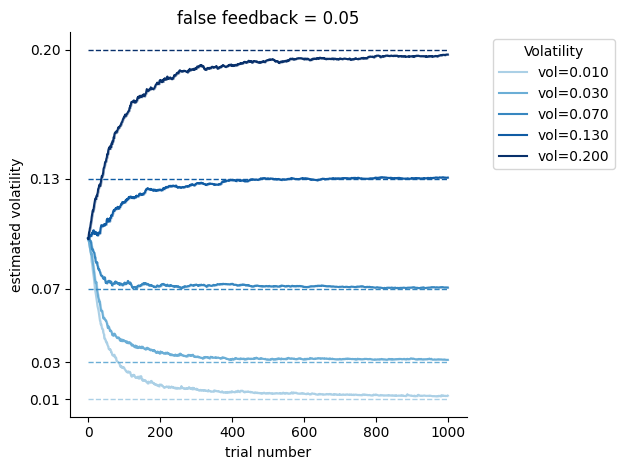

In [26]:
unique_vols = np.unique(vols)[1:-1]
estimations_means = np.hstack([nus_function_of_trials[:, (vols==v) * (ffs==0.05)].mean(axis=1, keepdims=True) for v in unique_vols])

nb_trials = 1000
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means[:, i, 1:nb_trials].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.fill_between(np.arange(1, nb_trials), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) - estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) + estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    ax.plot([0, nb_trials], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.05')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('figures/volatility_trial_number_dec2025.pdf')

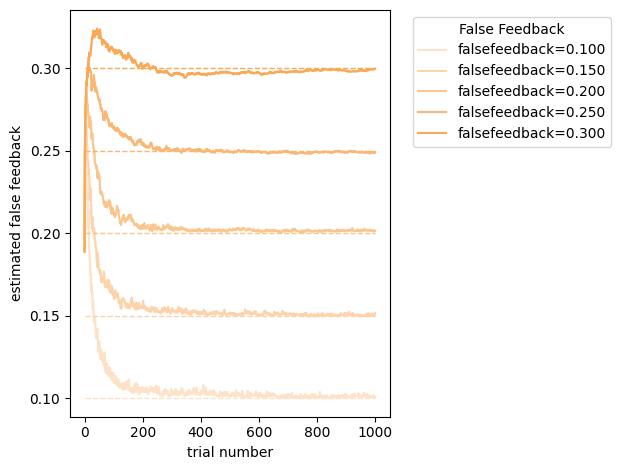

In [27]:
unique_falsefeedback = np.unique(ffs)[1:-1]
estimations_means = np.hstack([result['false_positive_rate'][None][:, (ffs==v) * (vols==0.03)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

nb_trials = 1000
# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, :nb_trials].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, nb_trials), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) - estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:nb_trials].mean(axis=0) + estimations_means[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, nb_trials], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
#plt.savefig('figures/falsefeedback_trial_number_dec2025.pdf')

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_3359/2568737844.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white


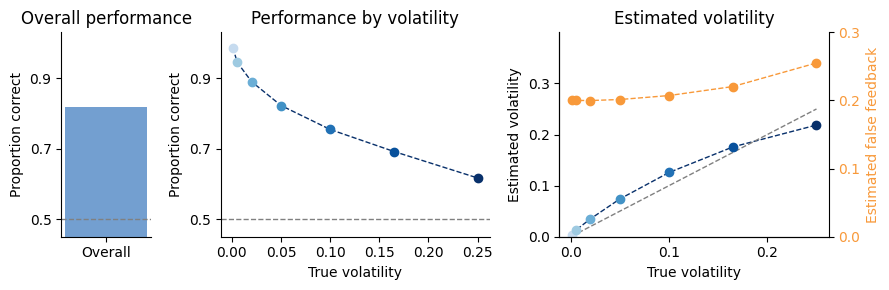

In [45]:
sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins_volatility + 1))
x_nus = (sorted_bins[:-1] + sorted_bins[1:]) / 2.

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = performance.mean()
axs[0].bar(0, overall_mean, color="#3877BC", capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by volatility (blues gradient for each)
mean_rewards = out_rewards_nus.mean(axis=0)
std_rewards = out_rewards_nus.std(axis=0)
n_bins = len(x_nus)
cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white
vol_lines = []

# Draw dashed line between markers
for i in range(n_bins):
    color = cmap(i + 2)  # skip first two lightest
    h = axs[1].errorbar(
        x_nus[i],
        mean_rewards[i],
        yerr=std_rewards[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None # only a few for legend
    )
    vol_lines.append(h)
# Draw dashed line connecting the markers
axs[1].plot(x_nus, mean_rewards, color=color, linestyle='--', linewidth=1, zorder=1)

axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True volatility')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by volatility')

mean_vol = nus_learned.mean(axis=0)
mean_falsefeedback = nus_falsefeedback_learned.mean(axis=0)
std_vol = nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
std_falsefeedback = nus_falsefeedback_learned_stds.mean(axis=0) / np.sqrt(nb_simul)

ax3 = axs[2]
ax3b = ax3.twinx()

vol_lines_third = []
# Draw errorbars for estimated volatility and dashed line between markers
for i in range(n_bins):
    color = cmap(i + 2)
    h = ax3.errorbar(
        x_nus[i],
        mean_vol[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None
    )
    vol_lines_third.append(h)
# Dashed line between the estimated volatility markers
ax3.plot(x_nus, mean_vol, color=color, linestyle='--', linewidth=1, zorder=1)

ax3.plot(x_nus, x_nus, color='gray', linestyle='--', linewidth=1, label='x = y')
ax3.set_yticks([0, 0.1, 0.2, 0.3])
ax3.set_xticks([0, 0.1, 0.2, 0.3])
ax3.set_ylim([0, 0.4])
ax3.spines[['right', 'top']].set_visible(False)
ax3.set_xlabel('True volatility')
ax3.set_ylabel('Estimated volatility')
ax3.set_title('Estimated volatility')

# Estimated false feedback errorbars (orange, right axis) and dashed line
ax3b.errorbar(
    x_nus,
    mean_falsefeedback,
    fmt='o',
    color="#F8993A",
    ecolor="#F8993A",
    elinewidth=1,
    capsize=0,
    label='Estimated false feedback'
)
# Dashed line between the estimated false feedback markers
ax3b.plot(x_nus, mean_falsefeedback, color="#F8993A", linestyle='--', linewidth=1, zorder=1)

ax3b.set_ylabel("Estimated false feedback", color="#F8993A")
ax3b.tick_params(axis='y', labelcolor="#F8993A")
ax3b.spines['top'].set_visible(False)
ax3b.set_yticks([0, 0.1, 0.2, 0.3])

plt.tight_layout()
plt.show()

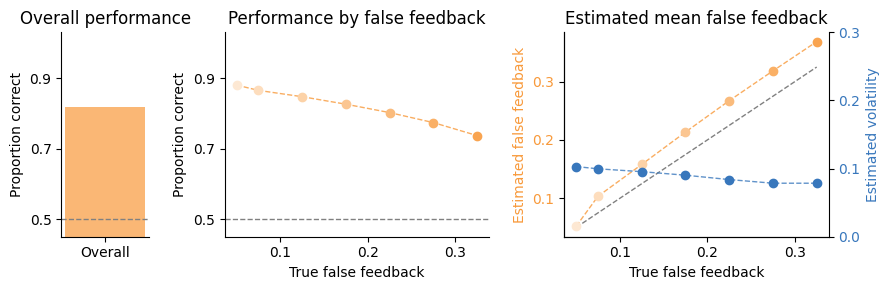

In [46]:
sorted_bins = np.percentile(false_positive_rate, np.linspace(0, 100, nb_bins_falsefeedback + 1))
x_falsefeedback = (sorted_bins[:-1] + sorted_bins[1:]) / 2.

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = out_rewards_falsefeedback.mean()
overall_std = out_rewards_falsefeedback.std() / np.sqrt(out_rewards_falsefeedback.size)
axs[0].bar(0, overall_mean, color="#F8993A", capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by false feedback (individual colored errorbars)
base_color = "#F8993A"
n_bins_ffb = len(x_falsefeedback)
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, n_bins_ffb + 2):
    interp = i / (n_bins_ffb + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
errorbar_colors = [colors[i + 2] for i in range(n_bins_ffb)]  # skip lightest

mean_rewards = out_rewards_falsefeedback.mean(axis=0)
std_rewards = out_rewards_falsefeedback_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_rewards, std_rewards)):
    axs[1].errorbar(
        x, m, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
    )
# Draw dashed line between the markers of the errorbars
axs[1].plot(
    x_falsefeedback,
    mean_rewards,
    color=base_color,
    linestyle='--',
    linewidth=1,
    zorder=1,
    alpha=0.8,
    label=None
)
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True false feedback')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by false feedback')

# Subplot 3: errorbars for inferred false feedback (estimates) and volatility estimate errorbars (blue)
mean_ffb = false_positive_rate_learned.mean(axis=0)
std_ffb = false_positive_rate_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_ffb, std_ffb)):
    axs[2].errorbar(
        x, m, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
        label=f"Estimated false feedback {x:.2f}" if i == 0 else None,  # label only once for legend
    )
# Draw dashed line between the markers of the errorbars
axs[2].plot(
    x_falsefeedback,
    mean_ffb,
    color=base_color,
    linestyle='--',
    linewidth=1,
    zorder=1,
    alpha=0.8,
    label=None
)
axs[2].plot(x_falsefeedback, x_falsefeedback, color='gray', linestyle='--', linewidth=1, label='x = y')

# Volatility estimate as errorbars, as requested
mean_nu = false_positive_rate_nus_learned.mean(axis=0)
std_nu = false_positive_rate_nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
axs2_right = axs[2].twinx()
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_nu, std_nu)):
    axs2_right.errorbar(
        x, m, fmt='o',
        color="#3877BC",
        ecolor="#3877BC",
        elinewidth=2,
        capsize=0,
        label="Estimated volatility" if i == 0 else None,
    )
# Draw dashed line between the volatility estimate markers
axs2_right.plot(
    x_falsefeedback,
    mean_nu,
    color="#3877BC",
    linestyle='--',
    linewidth=1,
    zorder=1,
    alpha=0.8,
    label=None
)

axs2_right.set_ylabel("Estimated volatility", color="#3877BC")
axs2_right.tick_params(axis='y', labelcolor="#3877BC")
axs2_right.spines['top'].set_visible(False)
axs2_right.set_yticks([0, 0.1, 0.2, 0.3])  # adjust y-ticks as needed
axs2_right.set_ylim([0, 0.3])

axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_xlabel('True false feedback')
axs[2].set_ylabel('Estimated false feedback', color="#F8993A")
axs[2].set_title('Estimated mean false feedback')
axs[2].tick_params(axis='y', labelcolor="#F8993A")

plt.tight_layout()
plt.show()